# 🌡️ Daily Climate Time Series Forecasting using Deep Learning
## ANN, RNN, LSTM, GRU - Regression Task
**Dataset:** Daily Delhi Climate (Train + Test)

This notebook forecasts mean temperature using ANN, RNN, LSTM, and GRU models.

---
## 1. 📦 Import Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.20.0


---
## 2. 📊 Dataset Understanding

TRAINING DATASET OVERVIEW
Shape: (1462, 5)

Columns: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure']

Data Types:
date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

Basic Statistics:
          meantemp     humidity   wind_speed  meanpressure
count  1462.000000  1462.000000  1462.000000   1462.000000
mean     25.495521    60.771702     6.802209   1011.104548
std       7.348103    16.769652     4.561602    180.231668
min       6.000000    13.428571     0.000000     -3.041667
25%      18.857143    50.375000     3.475000   1001.580357
50%      27.714286    62.625000     6.221667   1008.563492
75%      31.305804    72.218750     9.238235   1014.944901
max      38.714286   100.000000    42.220000   7679.333333

Missing Values:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Test Set Shape: (114, 5)

Numeric features: ['meantemp', 'humidity

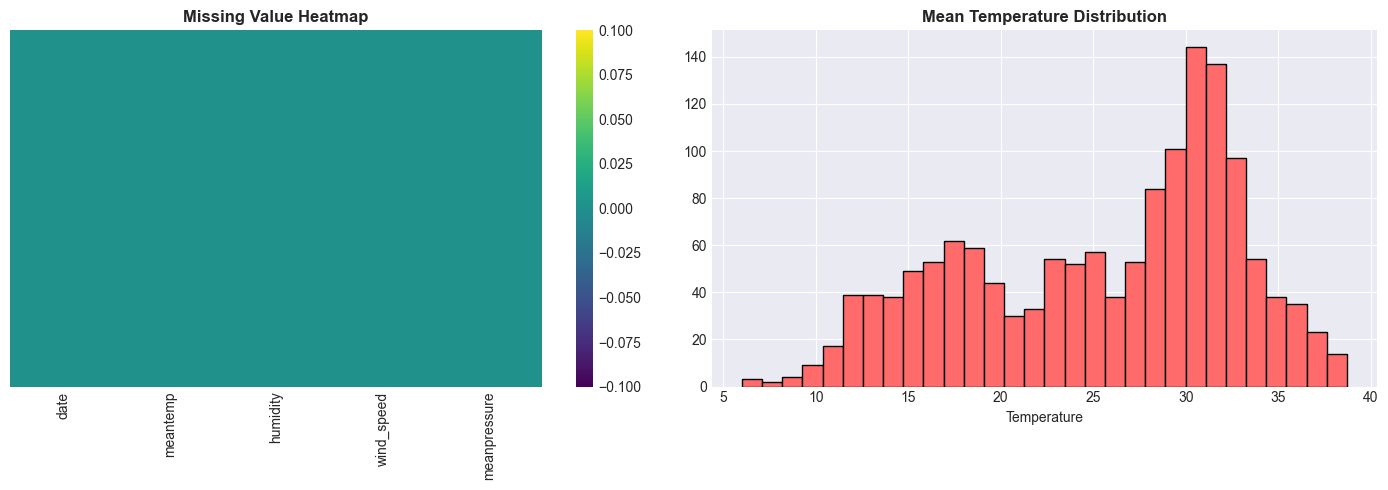

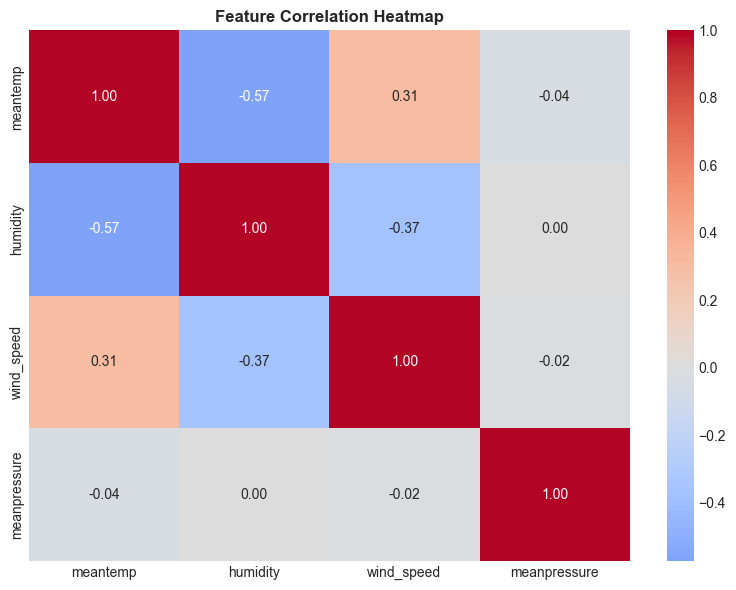

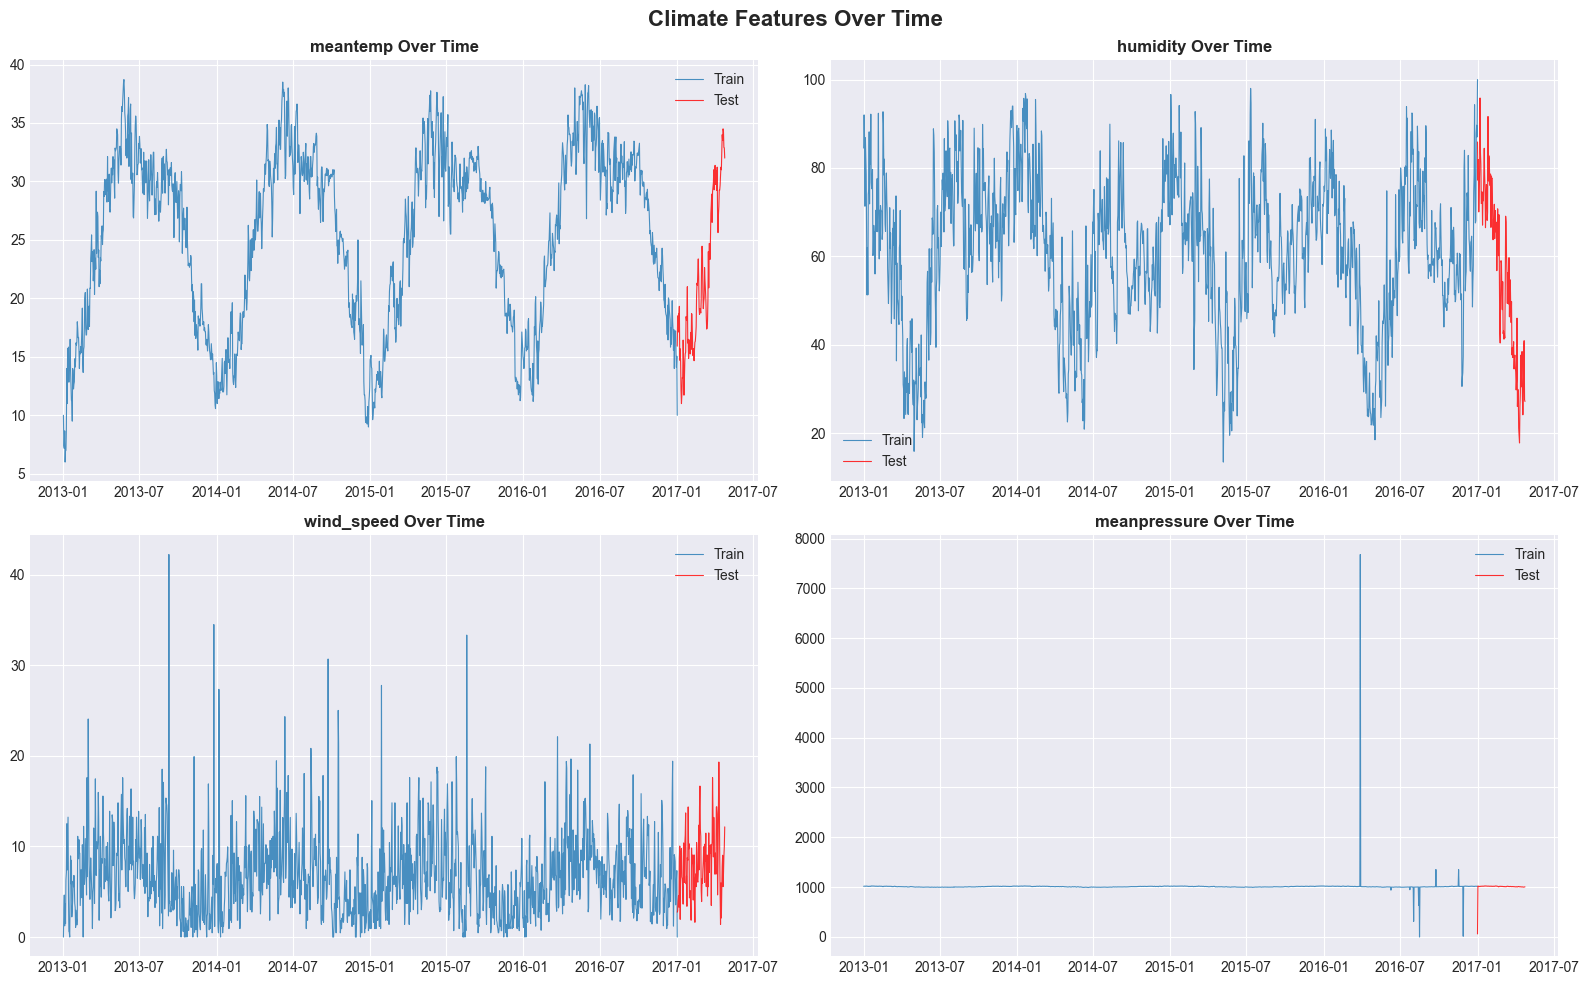

In [2]:

train_df = pd.read_csv('DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('DailyDelhiClimateTest.csv')

print("=" * 60)
print("TRAINING DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {train_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nData Types:\n{train_df.dtypes}")
print(f"\nBasic Statistics:\n{train_df.describe()}")
print(f"\nMissing Values:\n{train_df.isnull().sum()}")
print(f"\nTest Set Shape: {test_df.shape}")

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric features: {numeric_cols}")
print(f"Target variable: meantemp (continuous - regression task)")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(train_df.isnull(), cbar=True, yticklabels=False, ax=axes[0], cmap='viridis')
axes[0].set_title('Missing Value Heatmap', fontweight='bold')

train_df['meantemp'].hist(bins=30, ax=axes[1], color='#FF6B6B', edgecolor='black')
axes[1].set_title('Mean Temperature Distribution', fontweight='bold')
axes[1].set_xlabel('Temperature')
plt.tight_layout()
plt.savefig('climate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig('climate_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Time series plots
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 2, i % 2]
    ax.plot(train_df['date'], train_df[col], alpha=0.8, linewidth=0.8, label='Train')
    ax.plot(test_df['date'], test_df[col], alpha=0.8, linewidth=0.8, label='Test', color='red')
    ax.set_title(f'{col} Over Time', fontweight='bold')
    ax.legend()
plt.suptitle('Climate Features Over Time', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('climate_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. 🔧 Preprocessing

**Steps explained:**
- **Combine train/test** for consistent scaling
- **MinMaxScaler (0-1):** Normalizes features - essential for RNN convergence
- **Sequence windowing:** Create sliding windows of past N timesteps to predict next value
  This transforms the problem into a supervised learning task
- **Handle missing values** with forward fill

In [3]:

# Combine data
df = pd.concat([train_df, test_df], ignore_index=True)
df = df.sort_values('date').reset_index(drop=True)

# Handle missing/anomalous values
df[numeric_cols] = df[numeric_cols].fillna(method='ffill').fillna(method='bfill')

# Fix meanpressure outliers (values < 100 are likely errors)
df.loc[df['meanpressure'] < 100, 'meanpressure'] = df['meanpressure'].median()

# Scale features
feature_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[feature_cols])
scaled_df = pd.DataFrame(scaled_data, columns=feature_cols)

print(f"Scaled data shape: {scaled_df.shape}")
print(f"Scaled data range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")

# Create sequences for time series
def create_sequences(data, target_col_idx, window_size=30):
    """Create input sequences and targets for time series prediction.
    
    Args:
        data: Scaled numpy array of all features
        target_col_idx: Index of target column in data
        window_size: Number of past timesteps to use as input
    
    Returns:
        X: Input sequences (samples, window_size, features)
        y: Target values (samples,)
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

WINDOW_SIZE = 30
target_idx = feature_cols.index('meantemp')
X, y = create_sequences(scaled_data, target_idx, WINDOW_SIZE)

# Split (keep temporal order - no shuffling for time series!)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# For ANN: flatten the sequences
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\nSequence shape - X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Flattened - X_train_flat: {X_train_flat.shape}")


Scaled data shape: (1576, 4)
Scaled data range: [0.0000, 1.0000]

Sequence shape - X_train: (1236, 30, 4), X_test: (310, 30, 4)
Flattened - X_train_flat: (1236, 120)


---
## 4. 🏗️ Model Building

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
EPOCHS = 100
BATCH = 32
n_features = X_train.shape[2]
results = {}


### 4.1 ANN

In [6]:
print("\n" + "=" * 50)
print("MODEL 1: ANN")
print("=" * 50)

model_ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])
model_ann.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_ann.summary()

history_ann = model_ann.fit(X_train_flat, y_train, epochs=EPOCHS, batch_size=BATCH,
                            validation_split=0.2, callbacks=[early_stop], verbose=1)



MODEL 1: ANN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1366 - mae: 0.2711 - val_loss: 0.0288 - val_mae: 0.1384
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0335 - mae: 0.1476 - val_loss: 0.0461 - val_mae: 0.1812
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0265 - mae: 0.1315 - val_loss: 0.0403 - val_mae: 0.1789
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0216 - mae: 0.1154 - val_loss: 0.0257 - val_mae: 0.1383
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0191 - mae: 0.1096 - val_loss: 0.0286 - val_mae: 0.1443
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0163 - mae: 0.1019 - val_loss: 0.0299 - val_mae: 0.1489
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0156 - mae: 0.0989 - val_loss: 0.0342 - val_mae: 0.1592
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0149 - mae: 0.0990 - val_loss: 0.0297 - val_mae: 0.1477
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

### 4.2 Simple RNN

In [7]:
print("\n" + "=" * 50)
print("MODEL 2: Simple RNN")
print("=" * 50)

model_rnn = Sequential([
    SimpleRNN(128, activation='tanh', input_shape=(WINDOW_SIZE, n_features), return_sequences=True),
    Dropout(0.3),
    SimpleRNN(64, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_rnn.summary()

history_rnn = model_rnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                            validation_split=0.2, callbacks=[early_stop], verbose=1)



MODEL 2: Simple RNN


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 128)        │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,489 (123.00 KB)

 Trainable params: 31,489 (123.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.1080 - mae: 0.2484 - val_loss: 0.0157 - val_mae: 0.1036
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0438 - mae: 0.1638 - val_loss: 0.0069 - val_mae: 0.0632
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0269 - mae: 0.1303 - val_loss: 0.0066 - val_mae: 0.0629
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0237 - mae: 0.1229 - val_loss: 0.0149 - val_mae: 0.0999
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0212 - mae: 0.1151 - val_loss: 0.0068 - val_mae: 0.0648
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0176 - mae: 0.1056 - val_loss: 0.0122 - val_mae: 0.0914
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0176 - mae: 0.1044 - val_loss: 0.0079 - val_mae: 0.0701
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0144 - mae: 0.0936 - val_loss: 0.0173 - val_mae: 0.1105
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - lo

### 4.3 LSTM

In [8]:
print("\n" + "=" * 50)
print("MODEL 3: LSTM")
print("=" * 50)

model_lstm = Sequential([
    LSTM(128, activation='tanh', input_shape=(WINDOW_SIZE, n_features), return_sequences=True),
    Dropout(0.3),
    LSTM(64, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

history_lstm = model_lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                              validation_split=0.2, callbacks=[early_stop], verbose=1)



MODEL 3: LSTM


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,617 (467.25 KB)

 Trainable params: 119,617 (467.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0700 - mae: 0.1952 - val_loss: 0.0089 - val_mae: 0.0780
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0144 - mae: 0.0955 - val_loss: 0.0055 - val_mae: 0.0598
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0095 - mae: 0.0760 - val_loss: 0.0058 - val_mae: 0.0609
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0105 - mae: 0.0795 - val_loss: 0.0053 - val_mae: 0.0582
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0095 - mae: 0.0777 - val_loss: 0.0066 - val_mae: 0.0659
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0087 - mae: 0.0738 - val_loss: 0.0046 - val_mae: 0.0533
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - loss: 0.0082 - mae: 0.0709 - val_loss: 0.0044 - val_mae: 0.0526
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0085 - mae: 0.0721 - val_loss: 0.0044 - val_mae: 0.0522
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - 

### 4.4 GRU

In [9]:
print("\n" + "=" * 50)
print("MODEL 4: GRU")
print("=" * 50)

model_gru = Sequential([
    GRU(128, activation='tanh', input_shape=(WINDOW_SIZE, n_features), return_sequences=True),
    Dropout(0.3),
    GRU(64, activation='tanh'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])
model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_gru.summary()

history_gru = model_gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                            validation_split=0.2, callbacks=[early_stop], verbose=1)



MODEL 4: GRU


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 128)        │        51,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,817 (354.75 KB)

 Trainable params: 90,817 (354.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 121ms/step - loss: 0.0423 - mae: 0.1535 - val_loss: 0.0081 - val_mae: 0.0747
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0098 - mae: 0.0787 - val_loss: 0.0040 - val_mae: 0.0498
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0083 - mae: 0.0710 - val_loss: 0.0059 - val_mae: 0.0615
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0080 - mae: 0.0706 - val_loss: 0.0058 - val_mae: 0.0603
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0068 - mae: 0.0651 - val_loss: 0.0057 - val_mae: 0.0600
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0063 - mae: 0.0622 - val_loss: 0.0059 - val_mae: 0.0611
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0064 - mae: 0.0618 - val_loss: 0.0048 - val_mae: 0.0546
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 0.0063 - mae: 0.0631 - val_loss: 0.0051 - val_mae: 0.0561
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - 

---
## 5. 📈 Training Curves

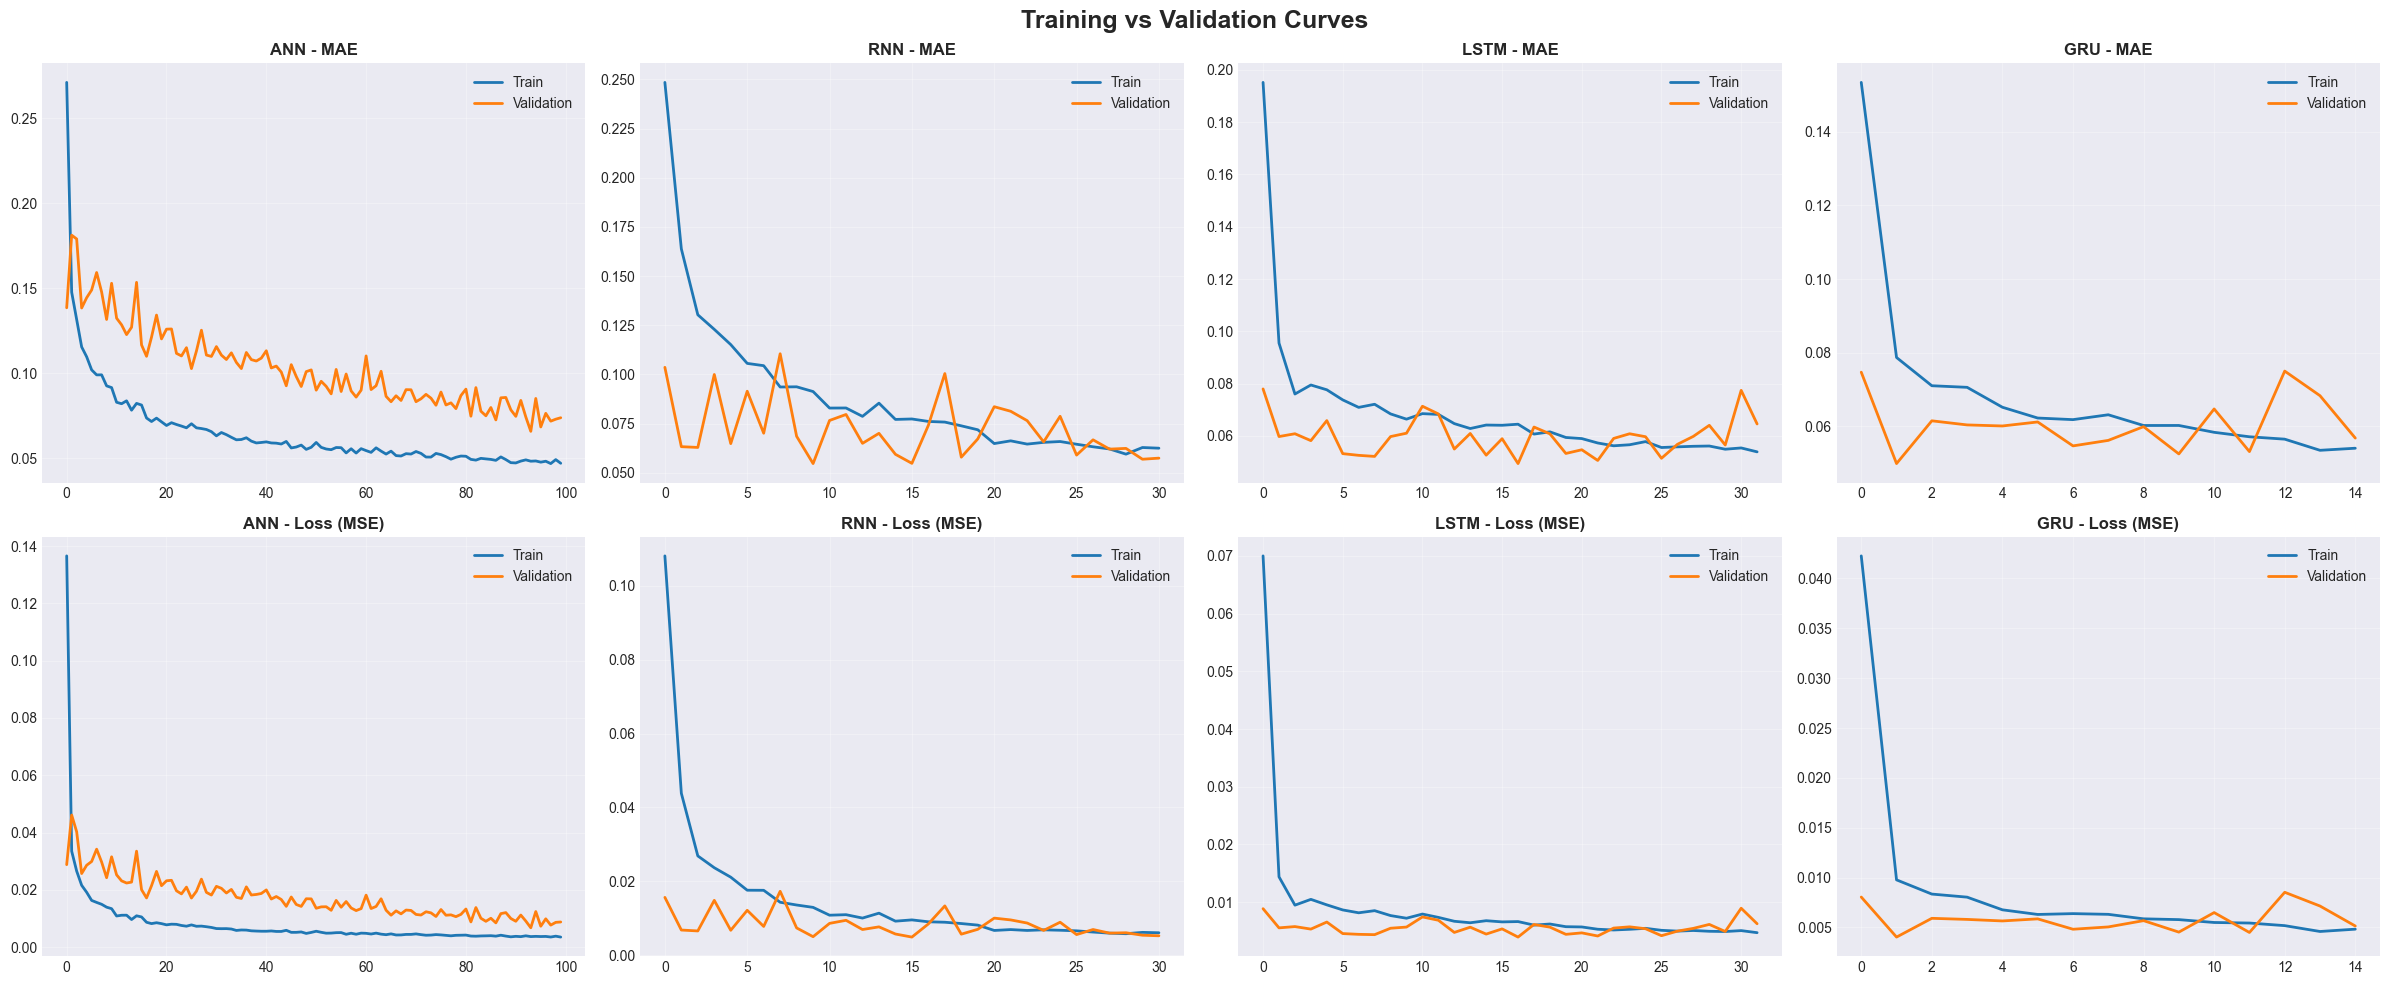

In [10]:

models_info = {'ANN': history_ann, 'RNN': history_rnn, 'LSTM': history_lstm, 'GRU': history_gru}

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for i, (name, hist) in enumerate(models_info.items()):
    axes[0, i].plot(hist.history['mae'], label='Train', linewidth=2)
    axes[0, i].plot(hist.history['val_mae'], label='Validation', linewidth=2)
    axes[0, i].set_title(f'{name} - MAE', fontweight='bold')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].plot(hist.history['loss'], label='Train', linewidth=2)
    axes[1, i].plot(hist.history['val_loss'], label='Validation', linewidth=2)
    axes[1, i].set_title(f'{name} - Loss (MSE)', fontweight='bold')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Curves', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('climate_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. 📋 Evaluation

In [11]:

def inverse_scale_temp(scaled_vals):
    """Inverse transform only the temperature column."""
    dummy = np.zeros((len(scaled_vals), len(feature_cols)))
    dummy[:, target_idx] = scaled_vals.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

def evaluate_regression(model, X_te, y_te, model_name, is_flat=False):
    y_pred_scaled = model.predict(X_te).flatten()
    y_pred = inverse_scale_temp(y_pred_scaled)
    y_actual = inverse_scale_temp(y_te)
    
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    
    print(f"\n{'=' * 40}")
    print(f"  {model_name} Results")
    print(f"{'=' * 40}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  R²:    {r2:.4f}")
    
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2,
            'y_pred': y_pred, 'y_actual': y_actual}

r_ann = evaluate_regression(model_ann, X_test_flat, y_test, 'ANN', True)
r_rnn = evaluate_regression(model_rnn, X_test, y_test, 'RNN')
r_lstm = evaluate_regression(model_lstm, X_test, y_test, 'LSTM')
r_gru = evaluate_regression(model_gru, X_test, y_test, 'GRU')

all_results = [r_ann, r_rnn, r_lstm, r_gru]


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

  ANN Results
  RMSE:  2.5510
  MAE:   2.1729
  R²:    0.8473
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step

  RNN Results
  RMSE:  2.1623
  MAE:   1.7766
  R²:    0.8903
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step

  LSTM Results
  RMSE:  2.3604
  MAE:   1.9041
  R²:    0.8693
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step

  GRU Results
  RMSE:  3.3057
  MAE:   2.7302
  R²:    0.7436


---
## 7. 📊 Visualization & Comparison

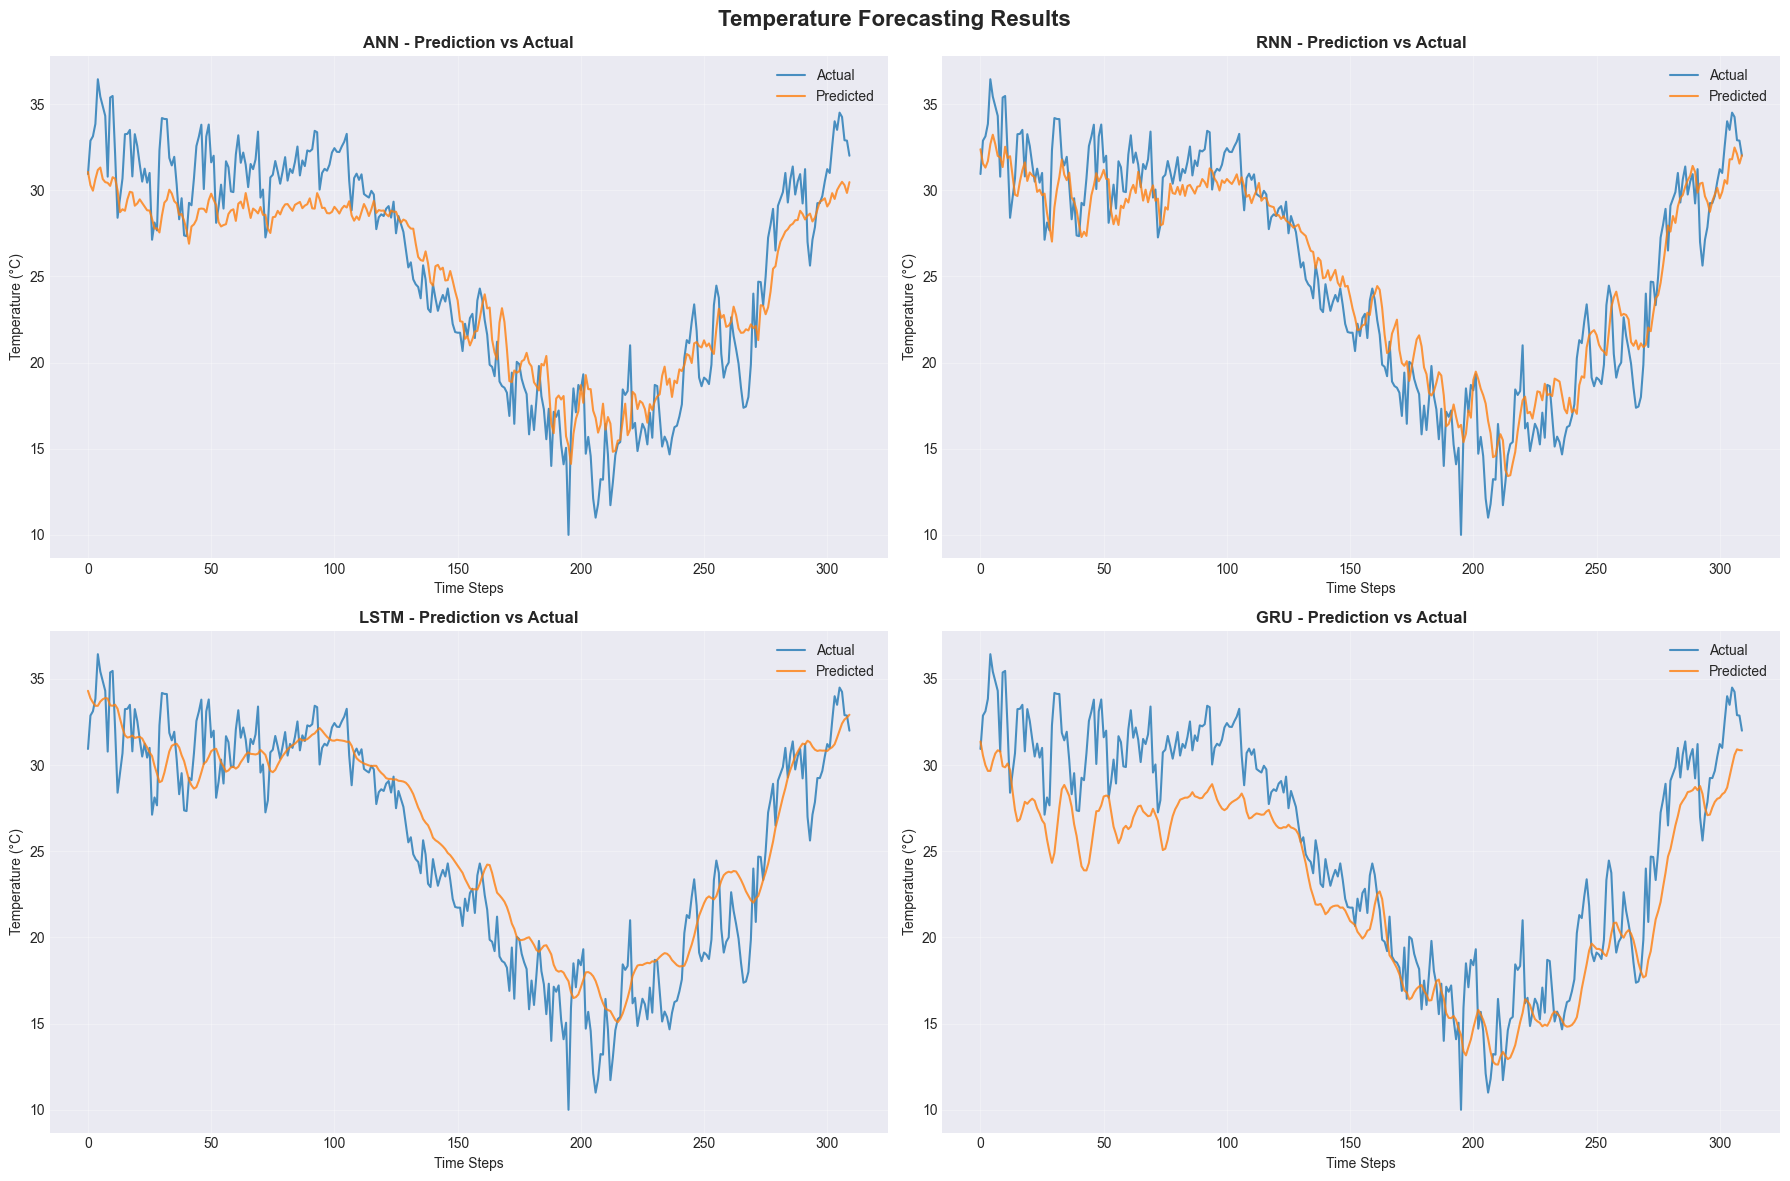


  MODEL COMPARISON TABLE
         RMSE     MAE      R²
Model                        
ANN    2.5510  2.1729  0.8473
RNN    2.1623  1.7766  0.8903
LSTM   2.3604  1.9041  0.8693
GRU    3.3057  2.7302  0.7436


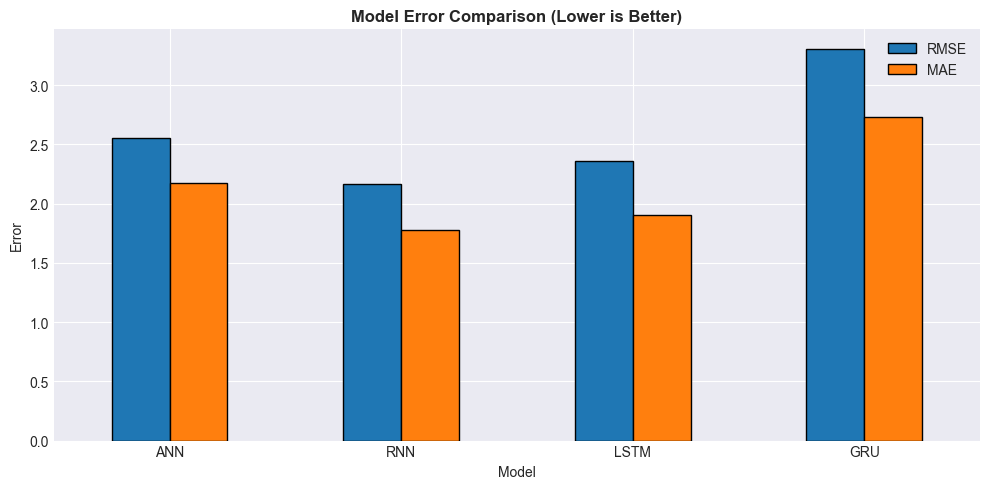


🏆 Best model: RNN (R² = 0.8903)

COMPARATIVE ANALYSIS:
- LSTM/GRU typically outperform Simple RNN on time series due to gating mechanisms
  that solve the vanishing gradient problem.
- ANN may struggle with temporal dependencies since it treats flattened input as
  independent features without sequential context.
- LSTM has 3 gates (forget, input, output) - most parameters, highest computational cost.
- GRU has 2 gates (reset, update) - fewer parameters, often comparable to LSTM performance.
- For this Delhi climate dataset, seasonal temperature patterns are strong,
  making even simpler models reasonably effective.



In [12]:

# Prediction vs Actual plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for i, r in enumerate(all_results):
    ax = axes[i // 2, i % 2]
    ax.plot(r['y_actual'], label='Actual', linewidth=1.5, alpha=0.8)
    ax.plot(r['y_pred'], label='Predicted', linewidth=1.5, alpha=0.8)
    ax.set_title(f"{r['Model']} - Prediction vs Actual", fontweight='bold')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Temperature Forecasting Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('climate_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparison table
comp_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'y_actual']} 
                        for r in all_results]).set_index('Model')
print("\n" + "=" * 60)
print("  MODEL COMPARISON TABLE")
print("=" * 60)
print(comp_df.round(4).to_string())

# Bar chart
comp_df[['RMSE', 'MAE']].plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Model Error Comparison (Lower is Better)', fontweight='bold')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('climate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = comp_df['R²'].idxmax()
print(f"\n🏆 Best model: {best} (R² = {comp_df.loc[best, 'R²']:.4f})")

# Comparative Discussion
print("""
COMPARATIVE ANALYSIS:
- LSTM/GRU typically outperform Simple RNN on time series due to gating mechanisms
  that solve the vanishing gradient problem.
- ANN may struggle with temporal dependencies since it treats flattened input as
  independent features without sequential context.
- LSTM has 3 gates (forget, input, output) - most parameters, highest computational cost.
- GRU has 2 gates (reset, update) - fewer parameters, often comparable to LSTM performance.
- For this Delhi climate dataset, seasonal temperature patterns are strong,
  making even simpler models reasonably effective.
""")


---
## 8. 💾 Model Saving

In [13]:

os.makedirs('saved_models', exist_ok=True)

model_ann.save('saved_models/climate_ann_model.keras')
model_rnn.save('saved_models/climate_rnn_model.keras')
model_lstm.save('saved_models/climate_lstm_model.keras')
model_gru.save('saved_models/climate_gru_model.keras')

with open('saved_models/climate_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('saved_models/climate_config.pkl', 'wb') as f:
    pickle.dump({'window_size': WINDOW_SIZE, 'feature_cols': feature_cols, 'target_idx': target_idx}, f)

comp_df.to_csv('saved_models/climate_comparison_results.csv')

print("✅ All models and artifacts saved to saved_models/")
print("🎉 Daily Climate Time Series Notebook Complete!")


✅ All models and artifacts saved to saved_models/
🎉 Daily Climate Time Series Notebook Complete!
